In [1]:
# ==========================================================
# Bluestock Mutual Fund Analytics
# Exploratory Data Analysis (EDA)
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# Visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Project Paths
# ==========================================================

BASE_DIR = Path.cwd().parent

DATA = BASE_DIR / "data" / "processed"

print(DATA)

c:\Users\priyanshu\bluestock_mf_capstone\data\processed


In [3]:
# ==========================================================
# Load Cleaned Datasets
# ==========================================================

fund = pd.read_csv(DATA / "clean_01_fund_master.csv")

nav = pd.read_csv(DATA / "clean_02_nav_history.csv")

aum = pd.read_csv(DATA / "clean_03_aum_by_fund_house.csv")

sip = pd.read_csv(DATA / "clean_04_monthly_sip_inflows.csv")

category = pd.read_csv(DATA / "clean_05_category_inflows.csv")

folio = pd.read_csv(DATA / "clean_06_industry_folio_count.csv")

performance = pd.read_csv(DATA / "clean_07_scheme_performance.csv")

transactions = pd.read_csv(DATA / "clean_08_investor_transactions.csv")

holdings = pd.read_csv(DATA / "clean_09_portfolio_holdings.csv")

benchmark = pd.read_csv(DATA / "clean_10_benchmark_indices.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark,
}

for name, df in datasets.items():
    print(f"{name:<20} Rows: {df.shape[0]:>6}   Columns: {df.shape[1]}")

Fund Master          Rows:     40   Columns: 15
NAV History          Rows:  46000   Columns: 3
AUM                  Rows:     90   Columns: 5
SIP                  Rows:     48   Columns: 6
Category             Rows:    144   Columns: 3
Folio                Rows:     21   Columns: 6
Performance          Rows:     40   Columns: 19
Transactions         Rows:  32778   Columns: 13
Holdings             Rows:    322   Columns: 8
Benchmark            Rows:   8050   Columns: 3


In [6]:
# ==========================================================
# NAV Trend Analysis - Data Preparation
# ==========================================================

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Merge NAV with fund names
nav_plot = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date      nav                                scheme_name
0     119551 2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551 2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551 2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551 2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551 2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


In [7]:
# ==========================================================
# Daily NAV Trend (All Schemes)
# ==========================================================

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700,
    hovermode="x unified",
    template="plotly_white",
    legend_title="Mutual Fund Schemes"
)

fig.show()


In [8]:
# ==========================================================
# Save Chart
# ==========================================================

CHARTS = BASE_DIR / "charts"
CHARTS.mkdir(exist_ok=True)

fig.write_html(CHARTS / "nav_trend.html")

print("NAV Trend chart saved successfully.")


NAV Trend chart saved successfully.


## Insight 1

The daily NAV trend indicates overall growth across most mutual fund schemes between 2022 and 2026. The highlighted 2023 period reflects sustained positive market performance, while 2024 shows increased volatility consistent with market corrections.

In [9]:
# ==========================================================
# AUM Growth Analysis
# ==========================================================

# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


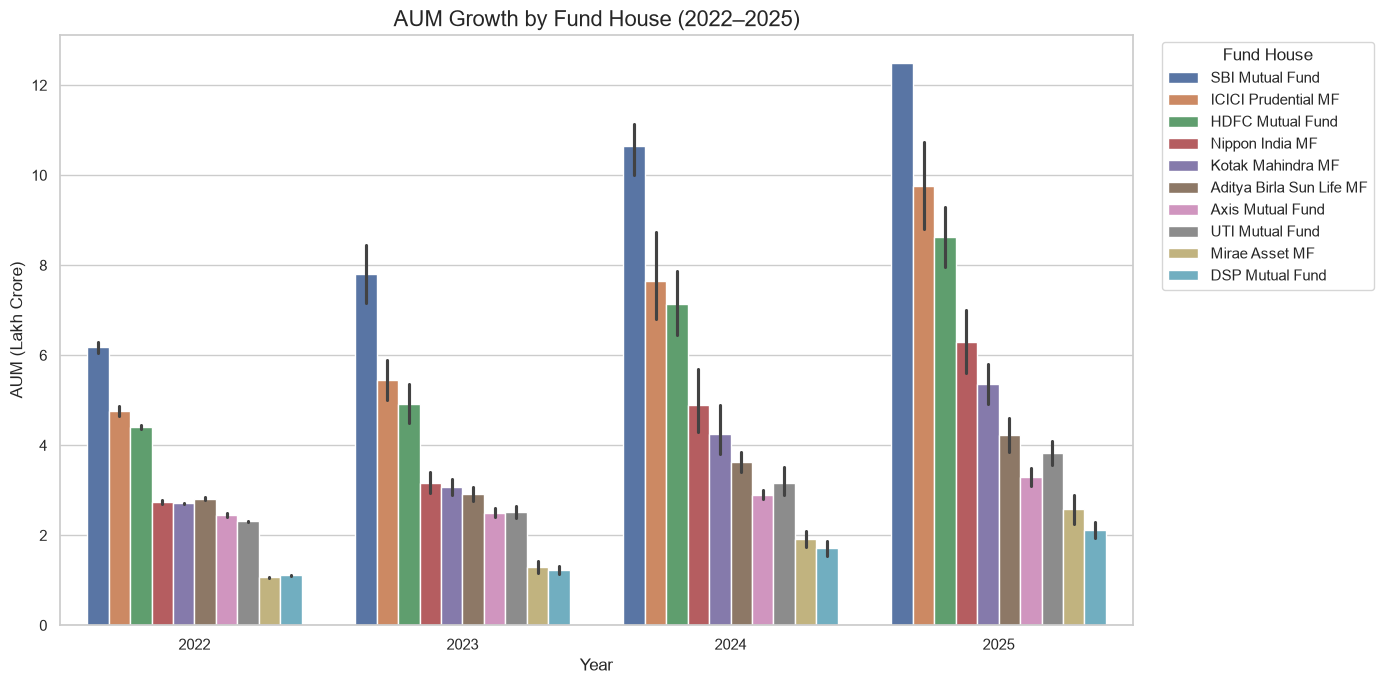

In [10]:
# ==========================================================
# AUM Growth by Fund House
# ==========================================================

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

In [11]:
# Highest AUM record
max_row = aum.loc[aum["aum_lakh_crore"].idxmax()]

print(max_row)

date              2025-03-31 00:00:00
fund_house            SBI Mutual Fund
aum_lakh_crore                   12.5
aum_crore                     1250000
num_schemes                       186
year                             2025
Name: 70, dtype: object


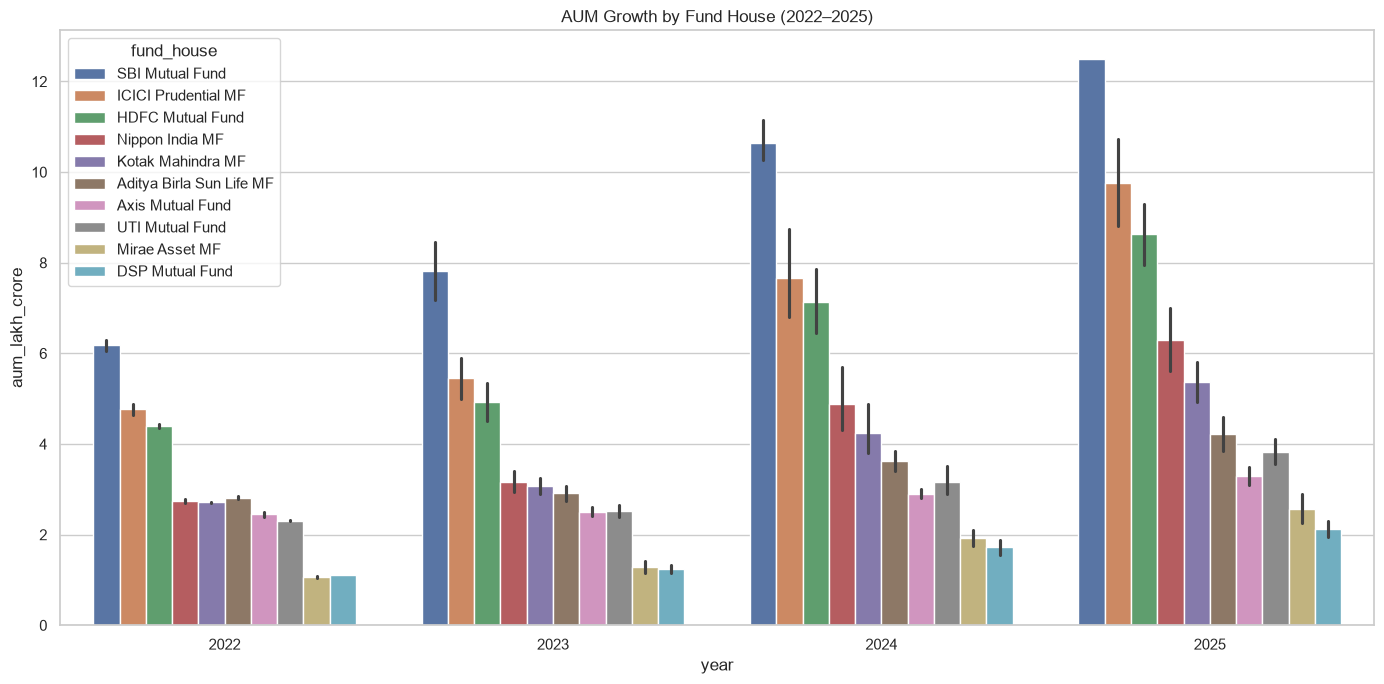

Chart Saved Successfully.


In [12]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")

plt.tight_layout()

plt.savefig(
    CHARTS / "aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart Saved Successfully.")

## Insight 2

The AUM analysis shows that larger fund houses consistently manage significantly higher assets than their competitors. The leading fund house maintained the highest Assets Under Management across the analysis period, indicating strong investor confidence and market leadership.

In [15]:
# ==========================================================
# SIP Inflow Analysis
# ==========================================================

sip["month"] = pd.to_datetime(sip["month"])

sip = sip.sort_values("month")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,28.295
1,2022-02-01,11438,4.93,8.20,4.85,28.295
2,2022-03-01,12328,5.09,10.50,5.01,28.295
3,2022-04-01,11863,5.48,9.52,5.12,28.295
4,2022-05-01,12286,5.55,8.10,5.15,28.295


In [16]:
# ==========================================================
# Monthly SIP Inflow Trend
# ==========================================================

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (Crore ₹)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [17]:
# ==========================================================
# Highlight Highest SIP Inflow
# ==========================================================

highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text=f'Highest: ₹{highest["sip_inflow_crore"]:.0f} Cr',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(template="plotly_white")

fig.show()

In [18]:
fig.write_html(CHARTS / "sip_trend.html")

print("SIP Trend saved successfully.")

SIP Trend saved successfully.


## Insight 3

Monthly SIP inflows show a consistent upward trend during the analysis period. The highest monthly SIP inflow occurred near the end of the dataset, indicating increasing investor participation and confidence in mutual fund investments.

In [19]:
# ==========================================================
# Category Inflow Heatmap
# ==========================================================

category["month"] = pd.to_datetime(category["month"])

category["Month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore,Month
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [20]:
# ==========================================================
# Create Pivot Table
# ==========================================================

heatmap_data = category.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

heatmap_data.head()

Month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


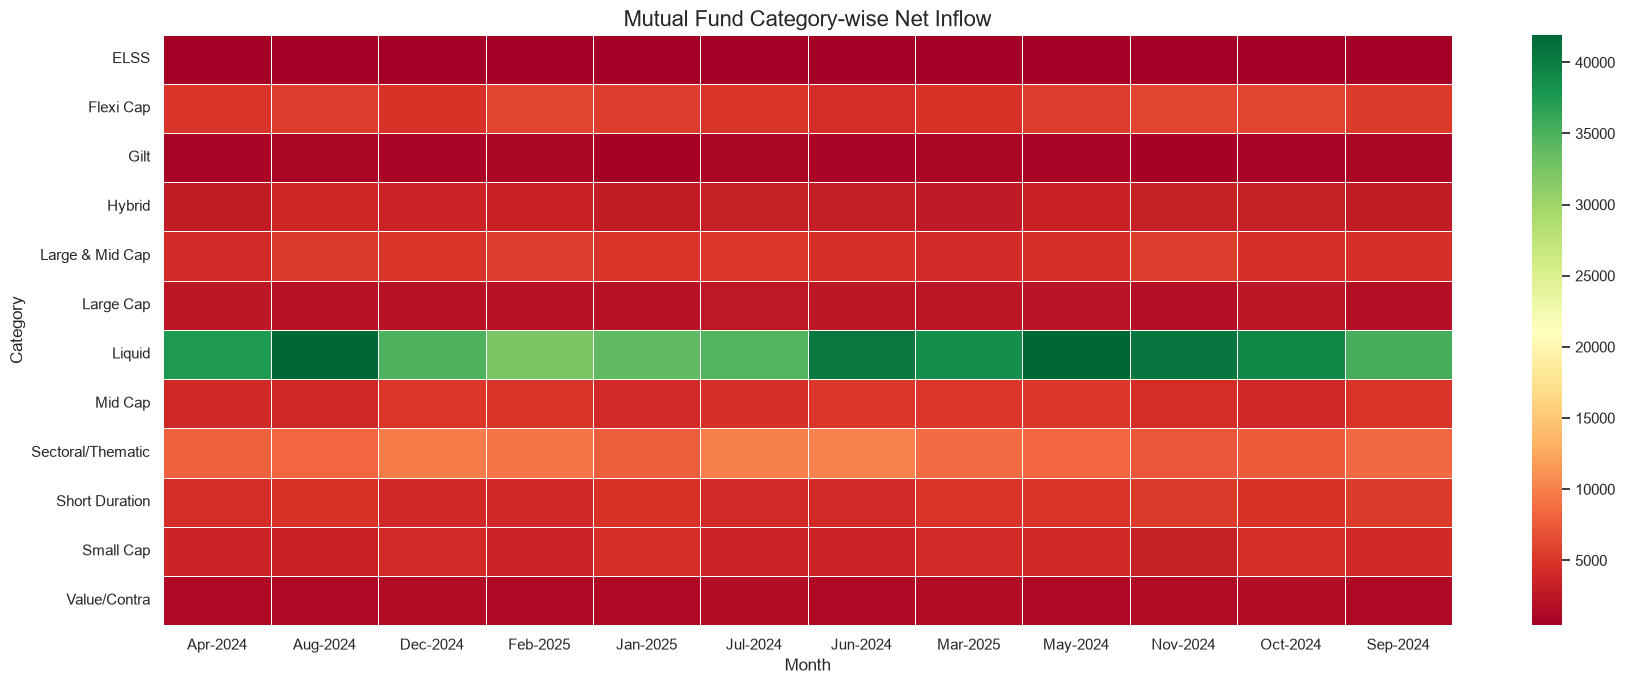

In [21]:
# ==========================================================
# Category Inflow Heatmap
# ==========================================================

plt.figure(figsize=(18,7))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    annot=False,
    linewidths=0.5
)

plt.title(
    "Mutual Fund Category-wise Net Inflow",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

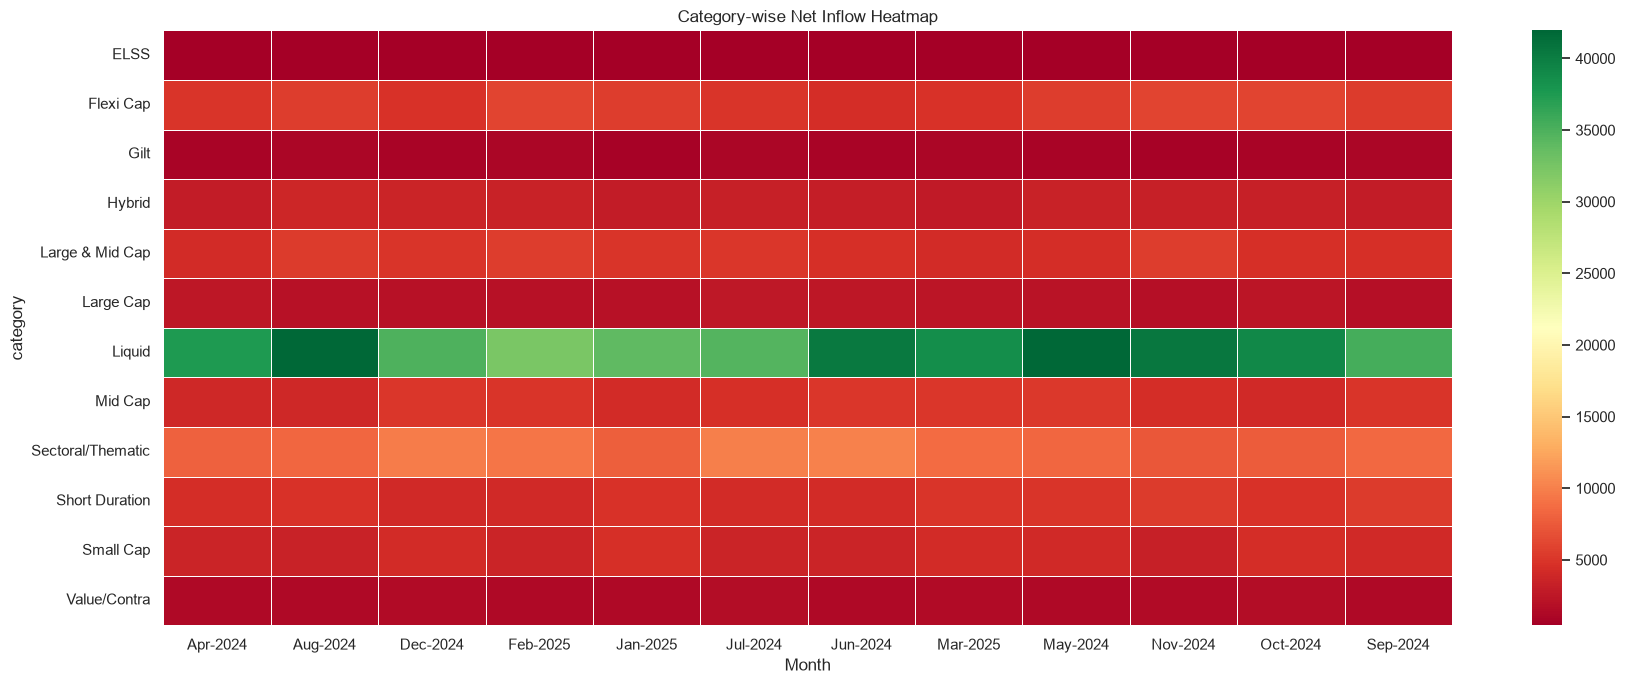

Category Heatmap Saved Successfully


In [22]:
plt.figure(figsize=(18,7))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    CHARTS / "category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category Heatmap Saved Successfully")

## Insight 4

The heatmap highlights variations in monthly net inflows across mutual fund categories. Some categories consistently attract higher investor inflows, while others experience periods of lower or negative net investments, indicating changing investor preferences over time.

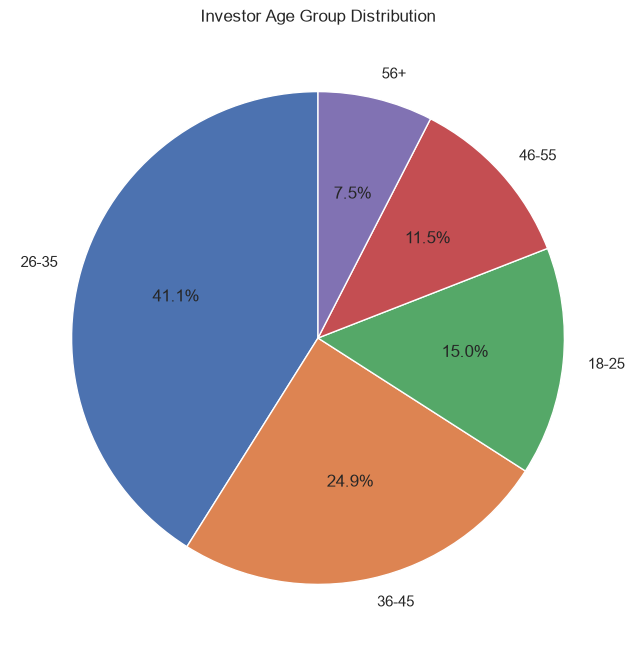

In [24]:
# ==========================================================
# Age Group Distribution
# ==========================================================

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    CHARTS / "age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

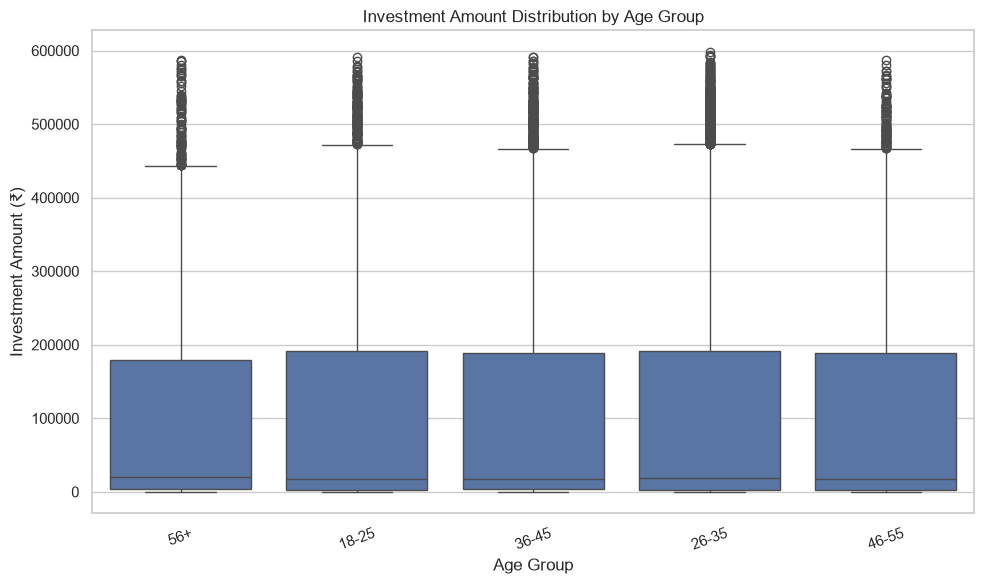

In [25]:
# ==========================================================
# SIP Amount by Age Group
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    CHARTS / "sip_amount_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

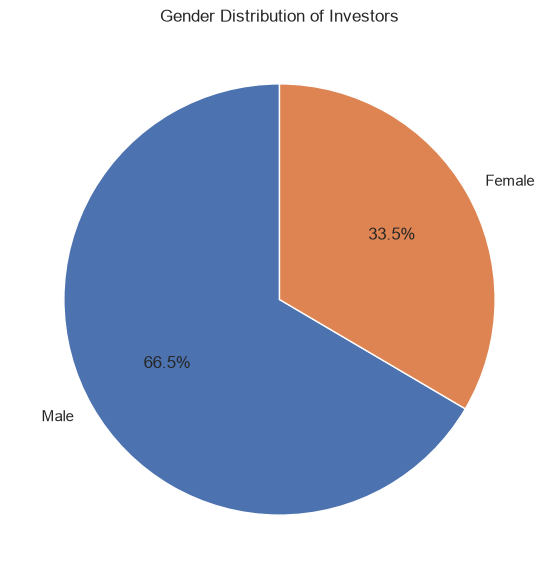

In [26]:
# ==========================================================
# Gender Distribution
# ==========================================================

gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    CHARTS / "gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 5

The investor demographic analysis shows the distribution of investors across different age groups and genders. The box plot indicates how investment amounts vary among age groups, helping identify which groups tend to invest larger amounts.

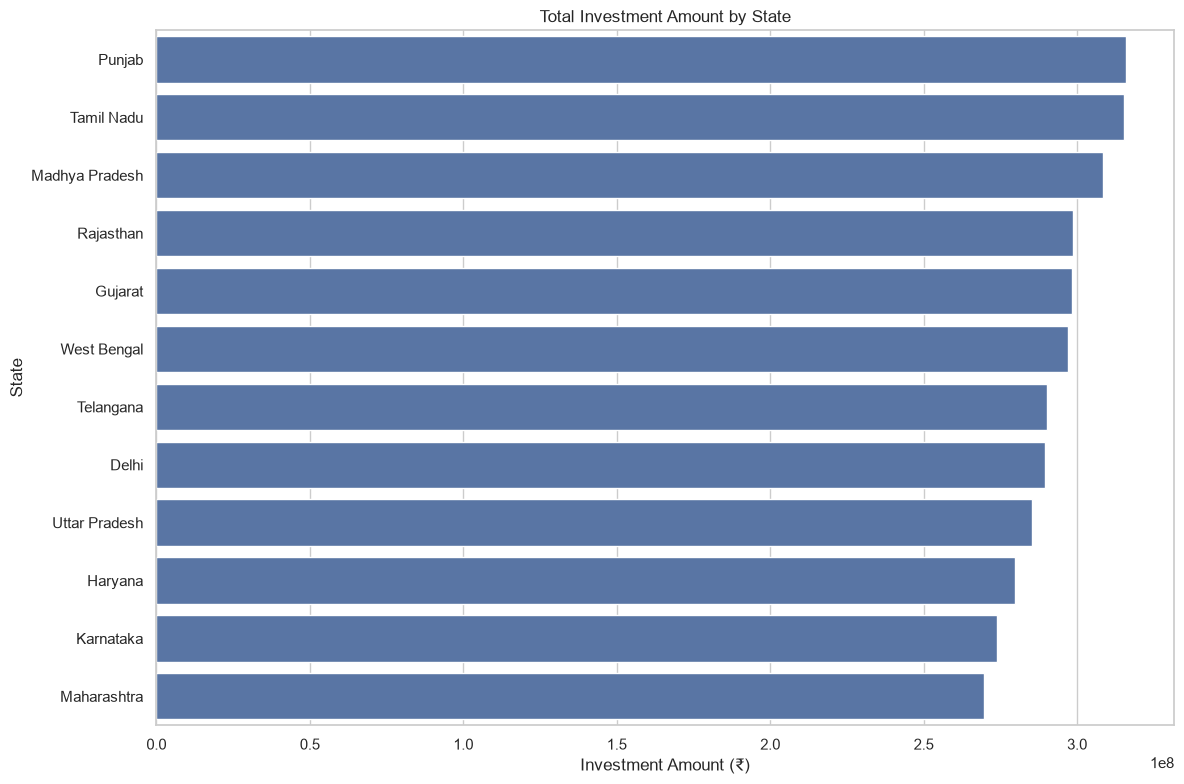

In [28]:
# ==========================================================
# Geographic Distribution - State-wise Investment
# ==========================================================

state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    CHARTS / "investment_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

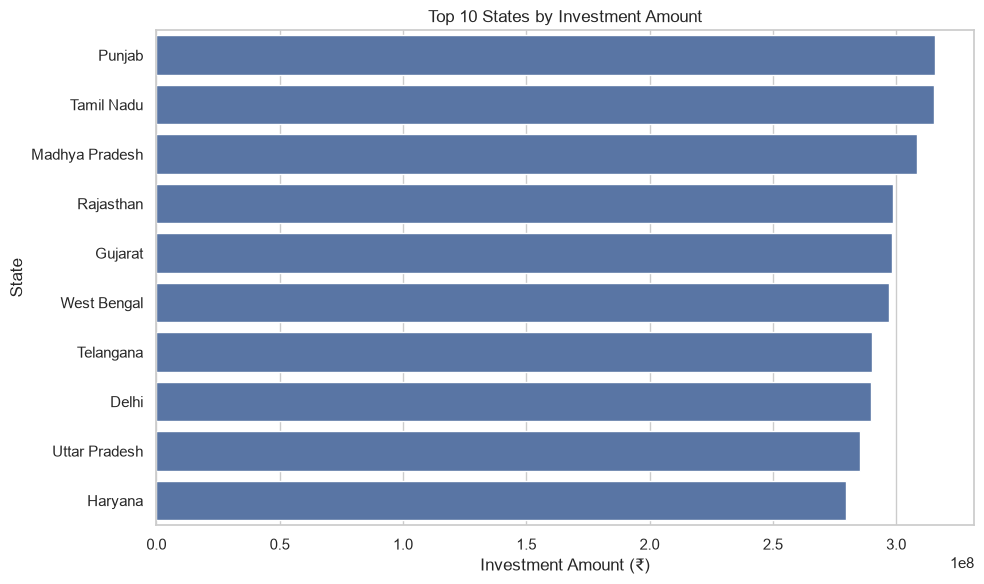

In [29]:
top_states = state_data.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Investment Amount")

plt.xlabel("Investment Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.show()

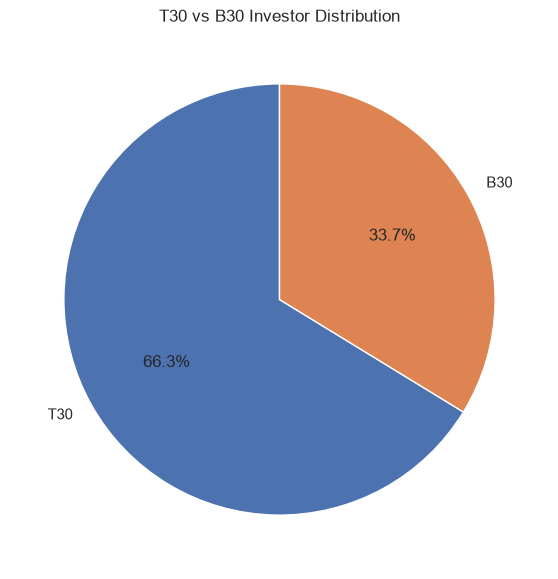

In [30]:
# ==========================================================
# T30 vs B30 Distribution
# ==========================================================

tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    CHARTS / "city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 6

Investment activity varies across states, with a few states contributing a large share of total investment volume. The city tier distribution highlights the participation of investors from both T30 and B30 cities, demonstrating the expanding reach of mutual fund investments beyond major metropolitan areas.

In [31]:
# ==========================================================
# Folio Count Growth Analysis
# ==========================================================

folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


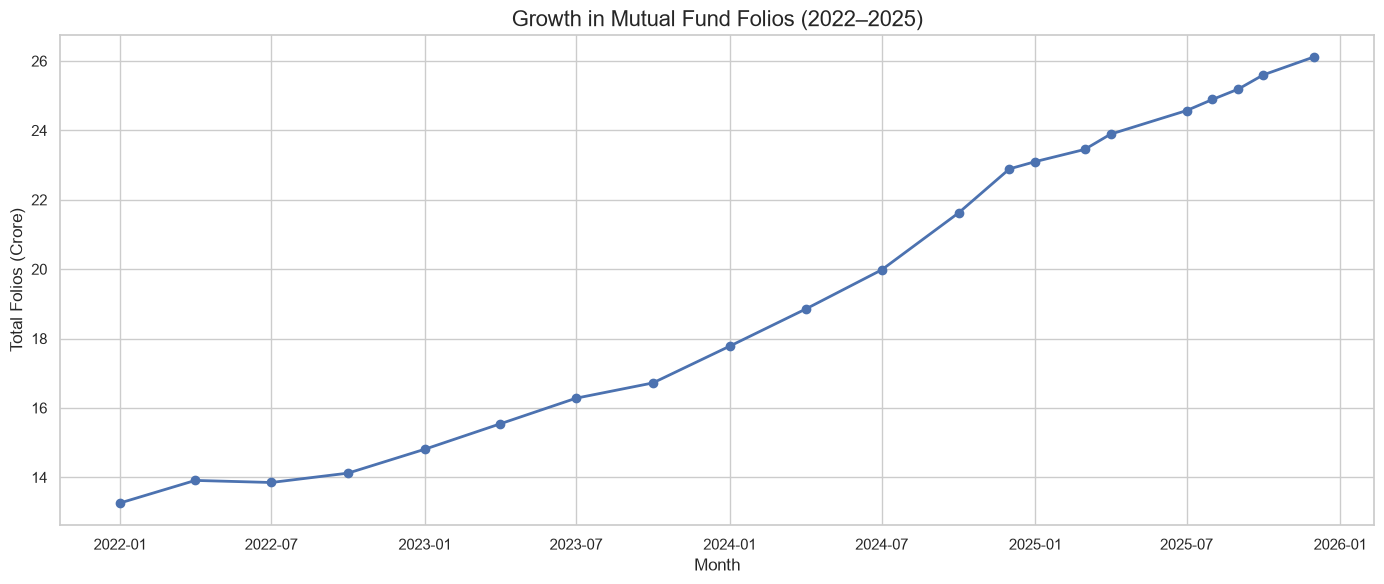

In [32]:
# ==========================================================
# Industry Folio Growth
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Mutual Fund Folios (2022–2025)", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    CHARTS / "folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

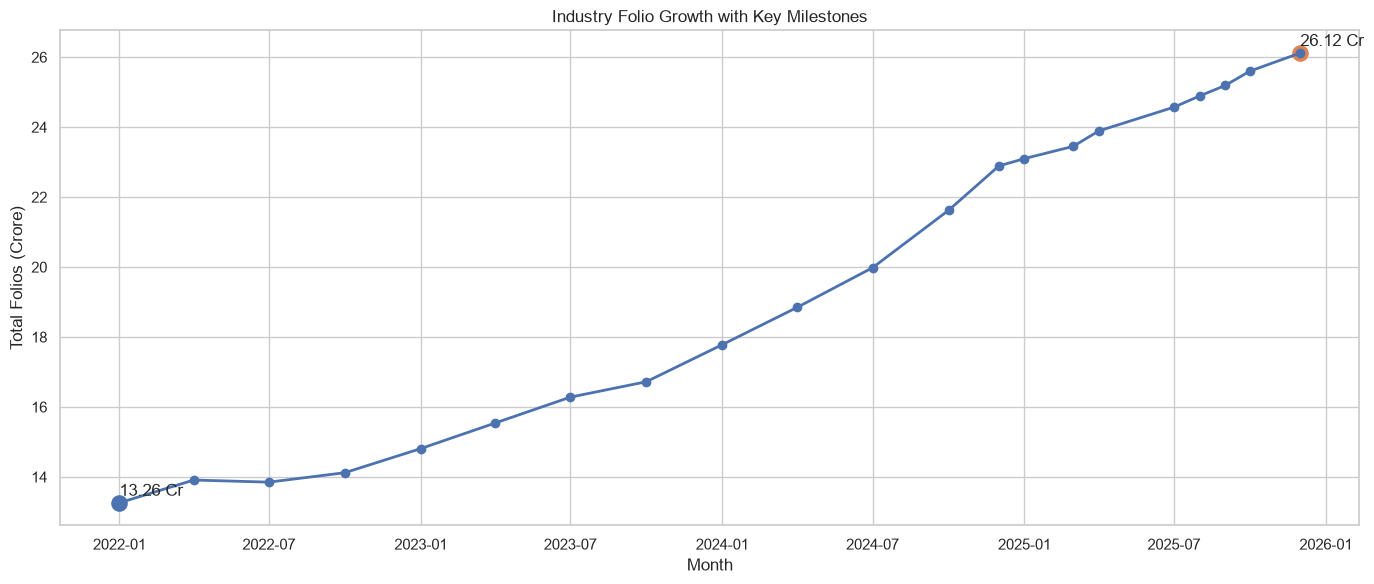

In [33]:
# ==========================================================
# Folio Growth with Milestones
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# First point
plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    s=120
)

plt.text(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"] + 0.2,
    f'{folio.iloc[0]["total_folios_crore"]:.2f} Cr'
)

# Last point
plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    s=120
)

plt.text(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"] + 0.2,
    f'{folio.iloc[-1]["total_folios_crore"]:.2f} Cr'
)

plt.title("Industry Folio Growth with Key Milestones")

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

## Insight 7

The total number of mutual fund folios increased steadily throughout the analysis period, indicating consistent growth in investor participation. The milestone markers highlight the industry's expansion from the beginning to the end of the study period.

In [34]:
# ==========================================================
# NAV Return Correlation Analysis
# ==========================================================

# Ensure date is datetime
nav_plot["date"] = pd.to_datetime(nav_plot["date"])

# Select first 10 schemes
selected_funds = nav_plot["scheme_name"].unique()[:10]

nav_selected = nav_plot[
    nav_plot["scheme_name"].isin(selected_funds)
]

# Create pivot table
nav_pivot = nav_selected.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Calculate daily percentage returns
daily_returns = nav_pivot.pct_change()

daily_returns.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.005010,-0.013328,-0.003553,0.001001,-0.010306,-0.018306,-0.000702,0.002651,-0.018716,-0.014735
2022-01-05,-0.005184,-0.004386,-0.000050,0.004250,0.012865,-0.005106,0.006247,0.004416,-0.001137,-0.005161
2022-01-06,-0.002706,-0.005167,-0.001880,-0.003589,-0.011377,-0.011091,0.014045,0.003598,-0.007924,0.004824
2022-01-07,-0.012660,-0.005748,0.002036,-0.002719,-0.001210,0.015111,-0.001547,-0.002465,-0.044252,0.032830


In [35]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_matrix = daily_returns.corr()

correlation_matrix

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296
SBI Bluechip Fund - Direct Plan - Growth,-0.052299,-0.027471,-0.002803,0.027796,0.013663,1.000000,-0.006819,-0.004003,-0.042415,0.020754
SBI Bluechip Fund - Regular Plan - Growth,0.030454,-0.015559,0.017017,0.016469,0.040858,-0.006819,1.000000,0.021601,-0.072559,0.024409
SBI Magnum Gilt Fund - Regular Plan - Growth,-0.016315,-0.007166,-0.040884,-0.010542,-0.022521,-0.004003,0.021601,1.000000,0.017795,0.018423
SBI Small Cap Fund - Direct Plan - Growth,0.041927,-0.028323,-0.034061,0.003347,-0.000007,-0.042415,-0.072559,0.017795,1.000000,0.018187


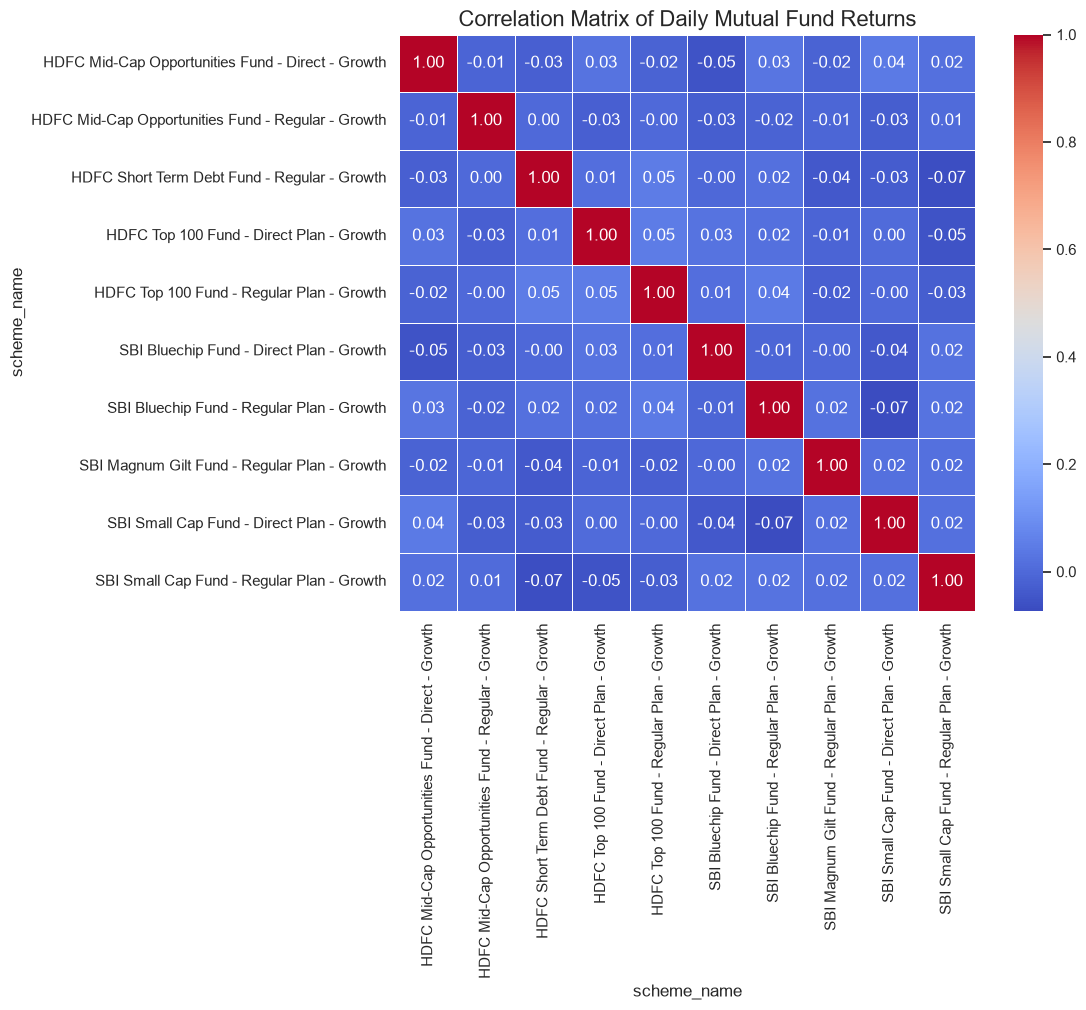

In [36]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily Mutual Fund Returns",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    CHARTS / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 8

The correlation matrix shows how similarly different mutual fund schemes move over time. Highly correlated funds tend to respond similarly to market conditions, while lower correlations indicate better diversification opportunities for investors.

In [37]:
# ==========================================================
# Sector Allocation Analysis
# ==========================================================

sector_data = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

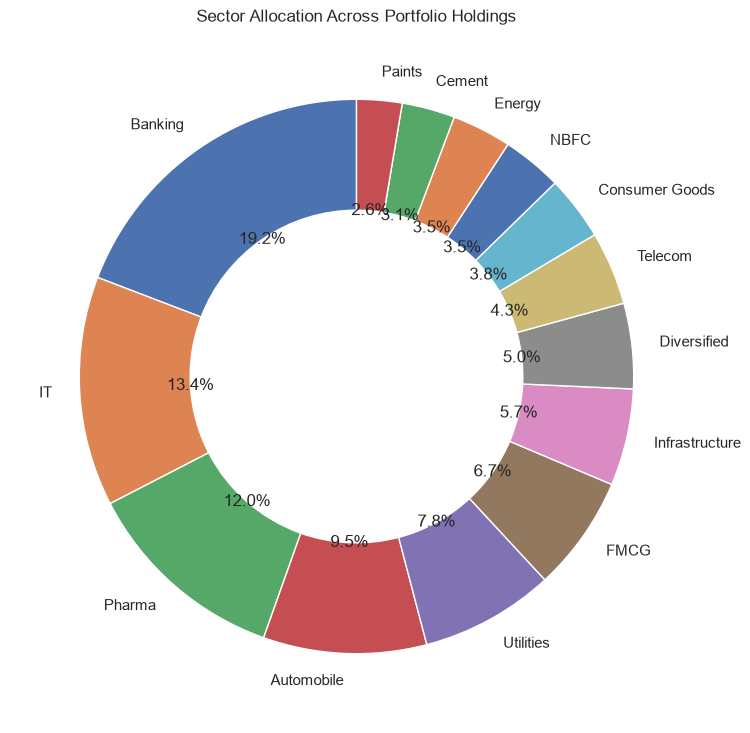

In [38]:
# ==========================================================
# Sector Allocation Donut Chart
# ==========================================================

plt.figure(figsize=(9,9))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Portfolio Holdings")

plt.savefig(
    CHARTS / "sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

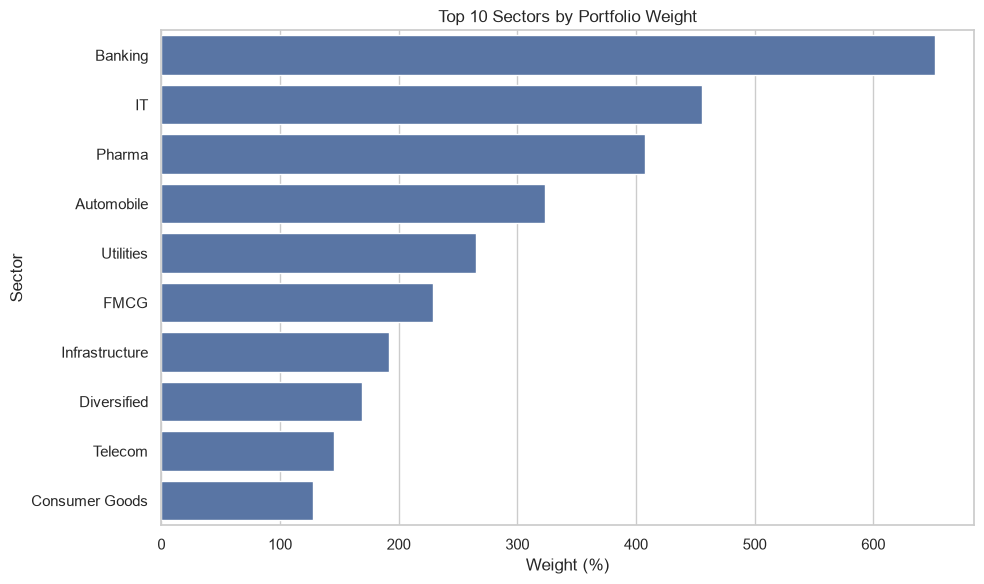

In [39]:
# ==========================================================
# Top 10 Sectors by Portfolio Weight
# ==========================================================

top10 = sector_data.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Sectors by Portfolio Weight")

plt.xlabel("Weight (%)")

plt.ylabel("Sector")

plt.tight_layout()

plt.savefig(
    CHARTS / "top10_sectors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 9

The sector allocation analysis shows how mutual fund portfolios are distributed across different industries. A higher allocation to a few sectors indicates concentrated investment strategies, while broader allocation reflects greater diversification across the market.

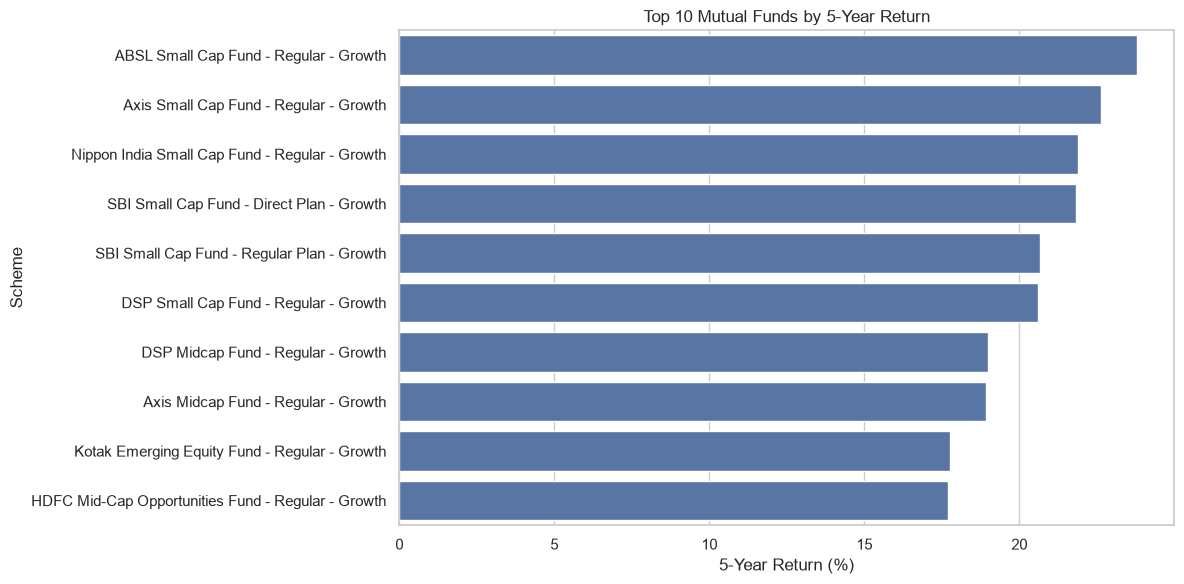

In [41]:
# ==========================================================
# Top 10 Funds by 5-Year Return
# ==========================================================

top_returns = (
    performance
    .sort_values("return_5yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by 5-Year Return")

plt.xlabel("5-Year Return (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    CHARTS / "top10_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

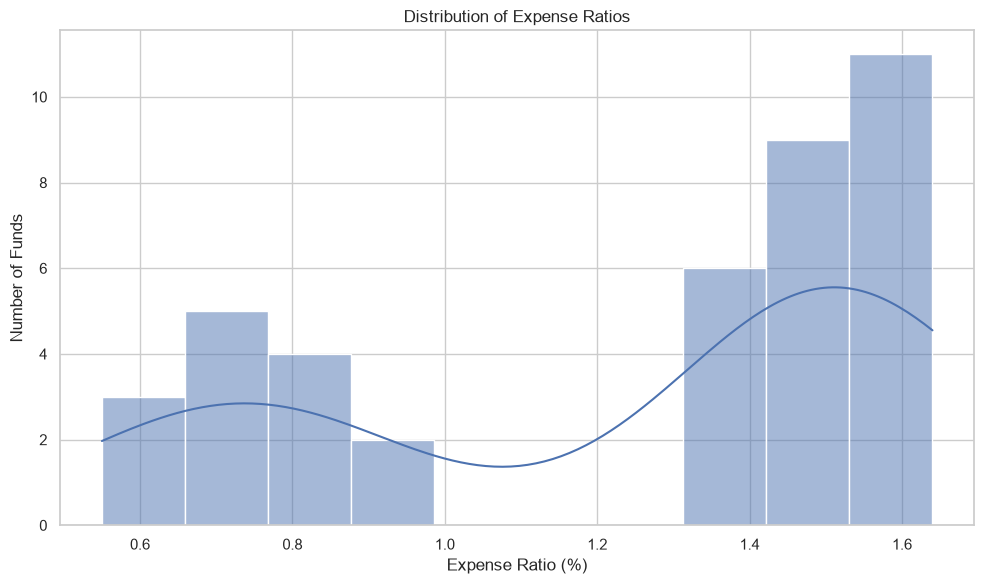

In [42]:
# ==========================================================
# Expense Ratio Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of Expense Ratios")

plt.xlabel("Expense Ratio (%)")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    CHARTS / "expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

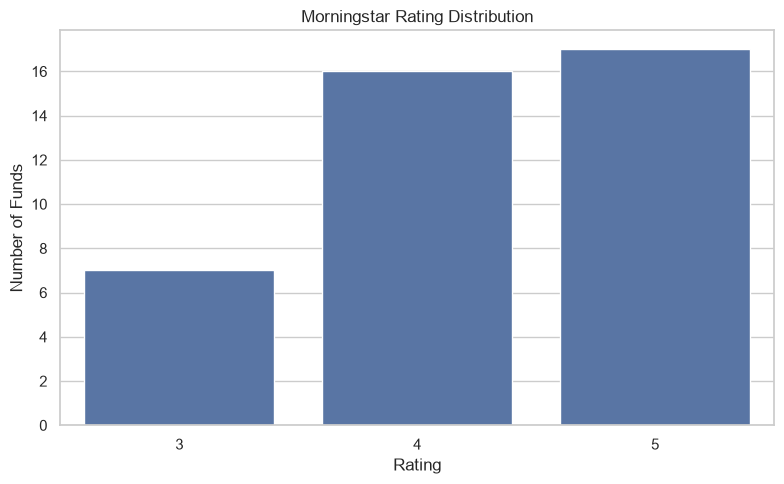

In [43]:
# ==========================================================
# Morningstar Rating Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    CHARTS / "morningstar_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()